In [23]:
import numpy as np

def filtre_prewitt():
    """Retourne les filtres Prewitt pour les directions x et y."""
    fx = np.array([[ -1, 0, 1],
                   [ -1, 0, 1],
                   [ -1, 0, 1]], dtype=np.float32)
    fy = np.array([[ 1,  1,  1],
                   [ 0,  0,  0],
                   [-1, -1, -1]], dtype=np.float32)
    return fx, fy

def filtre_sobel():
    """Retourne les filtres Sobel pour les directions x et y."""
    fx = np.array([[ -1, 0, 1],
                   [ -2, 0, 2],
                   [ -1, 0, 1]], dtype=np.float32)
    fy = np.array([[ 1,  2,  1],
                   [ 0,  0,  0],
                   [-1, -2, -1]], dtype=np.float32)
    return fx, fy

def filtre_roberts():
    """Retourne les filtres Roberts pour les directions x et y."""
    fx = np.array([[1, 0],
                   [0, -1]], dtype=np.float32)
    fy = np.array([[0, 1],
                   [-1, 0]], dtype=np.float32)
    return fx, fy

def filtre_laplacien():
    """Retourne le filtre Laplacien classique 3x3."""
    f = np.array([[0,  1, 0],
                  [1, -4, 1],
                  [0,  1, 0]], dtype=np.float32)
    return f

def filtre_scharr():
    """Retourne les filtres Scharr pour les directions x et y."""
    fx = np.array([[ -3, 0, 3],
                   [-10, 0,10],
                   [ -3, 0, 3]], dtype=np.float32)
    fy = np.array([[ 3, 10,  3],
                   [ 0,  0,  0],
                   [-3,-10, -3]], dtype=np.float32)
    return fx, fy

Filtres

In [16]:
def creation_filtre_aleatoire(taille, min_val=-1.0, max_val=1.0):
    """
    Crée un filtre carré aléatoire de taille (taille x taille).
    Les valeurs sont tirées uniformément entre min_val et max_val.
    """
    return np.random.uniform(min_val, max_val, (taille, taille)).astype(np.float32)


import numpy as np

def ajouter_padding(image, pad_y, pad_x, mode='constant', valeur=0):
    """
    Ajoute du padding à une image (2D ou 3D).
    pad_y : nombre de lignes à ajouter en haut et en bas
    pad_x : nombre de colonnes à ajouter à gauche et à droite
    mode : 'constant', 'edge', etc. (voir np.pad)
    valeur : valeur de remplissage si mode='constant'
    """
    if len(image.shape) == 2:
        pad_width = ((pad_y, pad_y), (pad_x, pad_x))
    elif len(image.shape) == 3:
        pad_width = ((pad_y, pad_y), (pad_x, pad_x), (0, 0))
    else:
        raise ValueError("Image doit être 2D ou 3D")
    return np.pad(image, pad_width, mode=mode, constant_values=valeur)

def cross_correlation(image, filtre, stride=1):
    """
    Applique une cross-corrélation entre l'image et le filtre avec un stride donné.
    image : 2D numpy array (niveaux de gris)
    filtre : 2D numpy array (filtre)
    stride : int (pas du déplacement)
    Retourne l'image filtrée.
    """
    h, w = image.shape
    fh, fw = filtre.shape
    pad_y = fh // 2
    pad_x = fw // 2
    image_pad = ajouter_padding(image, pad_y, pad_x)
    out_h = (h - fh) // stride + 1 if stride > 1 else h
    out_w = (w - fw) // stride + 1 if stride > 1 else w
    resultat = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(0, out_h):
        for j in range(0, out_w):
            y = i * stride
            x = j * stride
            region = image_pad[y:y+fh, x:x+fw]
            resultat[i, j] = np.sum(region * filtre)
    return resultat

def convolution(image, filtre, stride=1):
    """
    Applique une convolution entre l'image et le filtre avec un stride donné.
    image : 2D numpy array (niveaux de gris)
    filtre : 2D numpy array (filtre)
    stride : int (pas du déplacement)
    Retourne l'image convoluée.
    """
    # Retourner le filtre retourné (180°) pour la convolution
    filtre_conv = np.flipud(np.fliplr(filtre))
    return cross_correlation(image, filtre_conv, stride=stride)

# Exemple d'utilisation :
# img = ... # image 2D
# filtre = creation_filtre(3, valeur=1/9)  # filtre moyenneur 3x3
# img_filtre = cross_correlation(img, filtre, stride=1)
# img_filtre_stride2 = cross_correlation(img, filtre, stride=2)

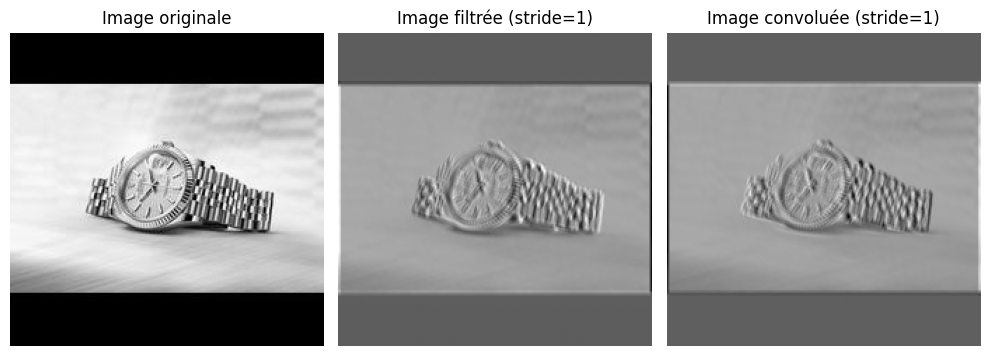

In [18]:
import cv2
import matplotlib.pyplot as plt

# Charger une image de la base (exemple)
image_path = "BD_images_resized/Montres_37/image371.jpg"
img_bgr = cv2.imread(image_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Créer un filtre aléatoire 3x3
filtre = creation_filtre_aleatoire(5, min_val=-1.0, max_val=1.0)

# Appliquer la cross-corrélation avec stride=1
img_filtre = cross_correlation(img_gray, filtre, stride=1)

img_filtre_conv = convolution(img_gray, filtre, stride=1)

# Afficher l'image originale et l'image filtrée
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Image originale")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(img_filtre, cmap='gray')
plt.title("Image filtrée (stride=1)")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(img_filtre_conv, cmap='gray')
plt.title("Image convoluée (stride=1)")
plt.axis('off')
plt.tight_layout()
plt.show()

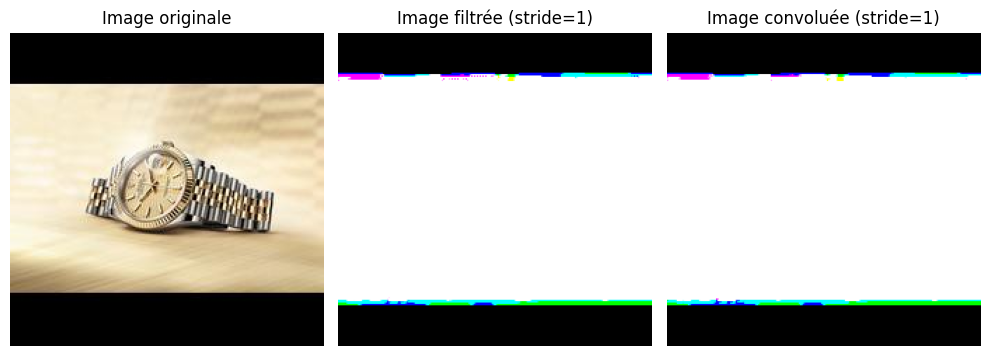

In [21]:
import cv2
import matplotlib.pyplot as plt

# Charger une image couleur
image_path = "BD_images_resized/Montres_37/image371.jpg"
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Créer un filtre aléatoire 5x5
filtre = creation_filtre_aleatoire(5, min_val=0, max_val=255)

# Appliquer la cross-corrélation sur chaque canal
img_filtre_r = cross_correlation(img_rgb[:, :, 0], filtre, stride=1)
img_filtre_g = cross_correlation(img_rgb[:, :, 1], filtre, stride=1)
img_filtre_b = cross_correlation(img_rgb[:, :, 2], filtre, stride=1)
img_filtre = np.stack([img_filtre_r, img_filtre_g, img_filtre_b], axis=2).clip(0, 255).astype(np.uint8)

img_filtre_conv_r = convolution(img_rgb[:, :, 0], filtre, stride=1)
img_filtre_conv_g = convolution(img_rgb[:, :, 1], filtre, stride=1)
img_filtre_conv_b = convolution(img_rgb[:, :, 2], filtre, stride=1)
img_filtre_conv = np.stack([img_filtre_conv_r, img_filtre_conv_g, img_filtre_conv_b], axis=2).clip(0, 255).astype(np.uint8)


# Afficher
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Image originale")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(img_filtre)
plt.title("Image filtrée (stride=1)")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(img_filtre_conv)
plt.title("Image convoluée (stride=1)")
plt.axis('off')
plt.tight_layout()
plt.show()

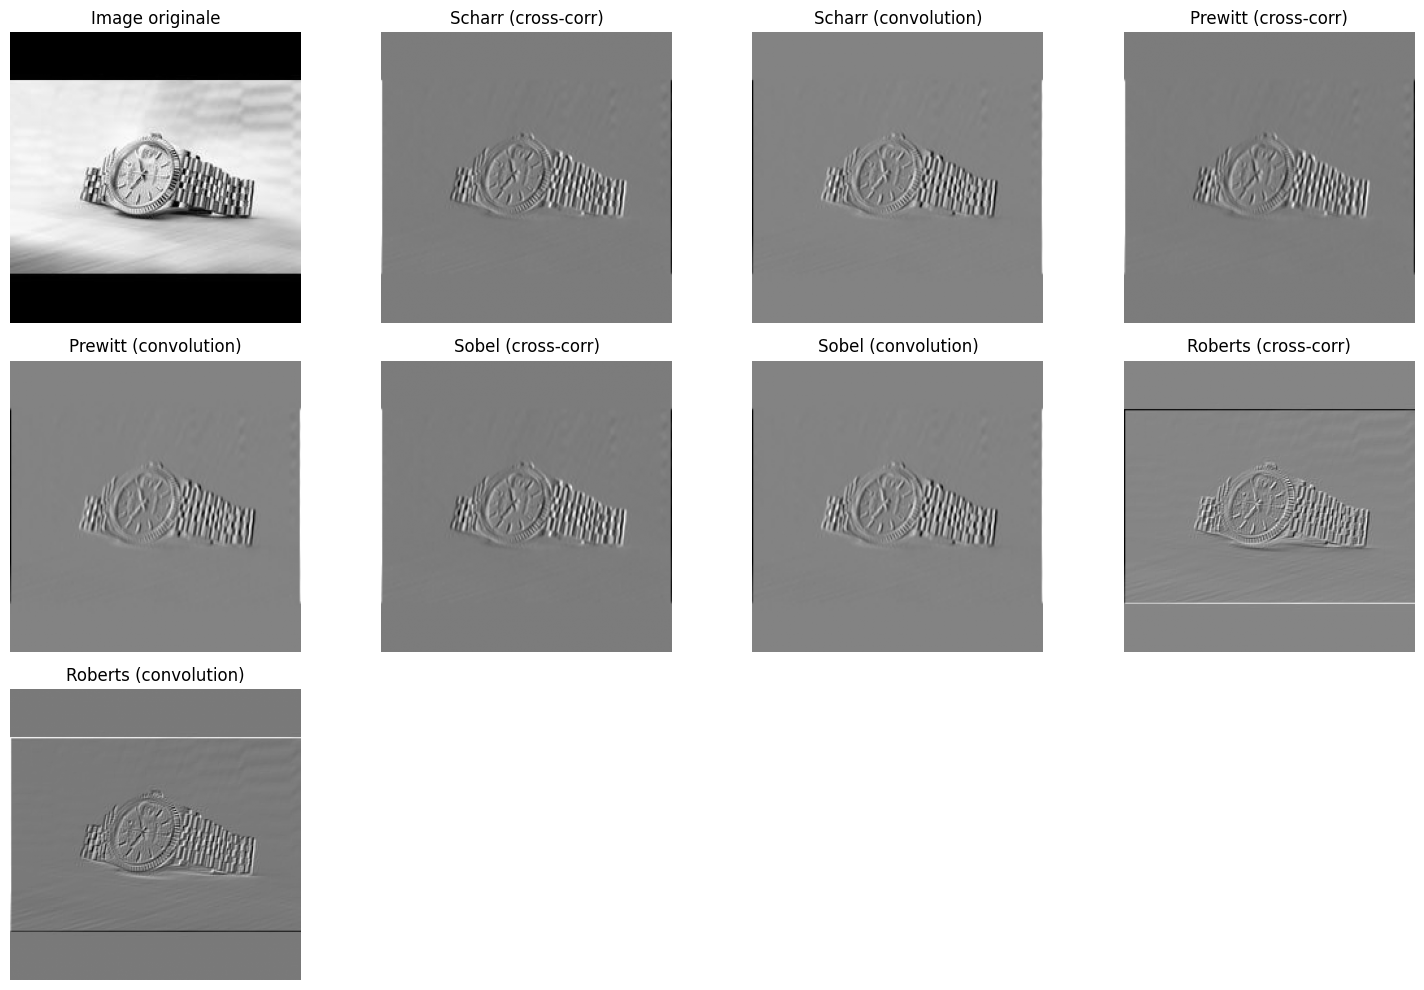

In [36]:
# applique tout les filtres (schar, prewitt, sobel, robert, laplacien) en convolution et cross-correlation sur une image en niveaux de gris et une image couleur

import cv2
import matplotlib.pyplot as plt
# Charger une image de la base (exemple)
image_path = "BD_images_resized/Montres_37/image371.jpg"
img_bgr = cv2.imread(image_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
# Créer les filtres
filtre_schar_x, filtre_schar_y = filtre_scharr()
filtre_prewitt_x, filtre_prewitt_y = filtre_prewitt()
filtre_sobel_x, filtre_sobel_y = filtre_sobel()
filtre_roberts_x, filtre_roberts_y = filtre_roberts()
#filtre_laplacien = filtre_laplacien()
# Appliquer la cross-corrélation et la convolution avec stride=1 pour chaque filtre
img_schar = cross_correlation(img_gray, filtre_schar_x, stride=1)
img_schar_conv = convolution(img_gray, filtre_schar_x, stride=1)
img_prewitt = cross_correlation(img_gray, filtre_prewitt_x, stride=1)
img_prewitt_conv = convolution(img_gray, filtre_prewitt_x, stride=1)
img_sobel = cross_correlation(img_gray, filtre_sobel_x, stride=1)
img_sobel_conv = convolution(img_gray, filtre_sobel_x, stride=1)
img_roberts = cross_correlation(img_gray, filtre_roberts_x, stride=1)
img_roberts_conv = convolution(img_gray, filtre_roberts_x, stride=1)
#img_laplacien = cross_correlation(img_gray, filtre_laplacien, stride=1)
#img_laplacien_conv = convolution(img_gray, filtre_laplacien, stride=1)
# Afficher les résultats
plt.figure(figsize=(15,10))
plt.subplot(3,4,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Image originale")
plt.axis('off')
plt.subplot(3,4,2)
plt.imshow(img_schar, cmap='gray')
plt.title("Scharr (cross-corr)")
plt.axis('off')
plt.subplot(3,4,3)
plt.imshow(img_schar_conv, cmap='gray')
plt.title("Scharr (convolution)")
plt.axis('off')
plt.subplot(3,4,4)
plt.imshow(img_prewitt, cmap='gray')
plt.title("Prewitt (cross-corr)")
plt.axis('off')
plt.subplot(3,4,5)
plt.imshow(img_prewitt_conv, cmap='gray')
plt.title("Prewitt (convolution)")
plt.axis('off')
plt.subplot(3,4,6)
plt.imshow(img_sobel, cmap='gray')
plt.title("Sobel (cross-corr)")
plt.axis('off')
plt.subplot(3,4,7)
plt.imshow(img_sobel_conv, cmap='gray')
plt.title("Sobel (convolution)")  
plt.axis('off')
plt.subplot(3,4,8)
plt.imshow(img_roberts, cmap='gray')
plt.title("Roberts (cross-corr)")
plt.axis('off')
plt.subplot(3,4,9)
plt.imshow(img_roberts_conv, cmap='gray')
plt.title("Roberts (convolution)")
plt.axis('off')
"""plt.subplot(3,4,10)
plt.imshow(img_laplacien, cmap='gray')
plt.title("Laplacien (cross-corr)")
plt.axis('off')
plt.subplot(3,4,11)
plt.imshow(img_laplacien_conv, cmap='gray')
plt.title("Laplacien (convolution)")
plt.axis('off')"""
plt.tight_layout()
plt.show()





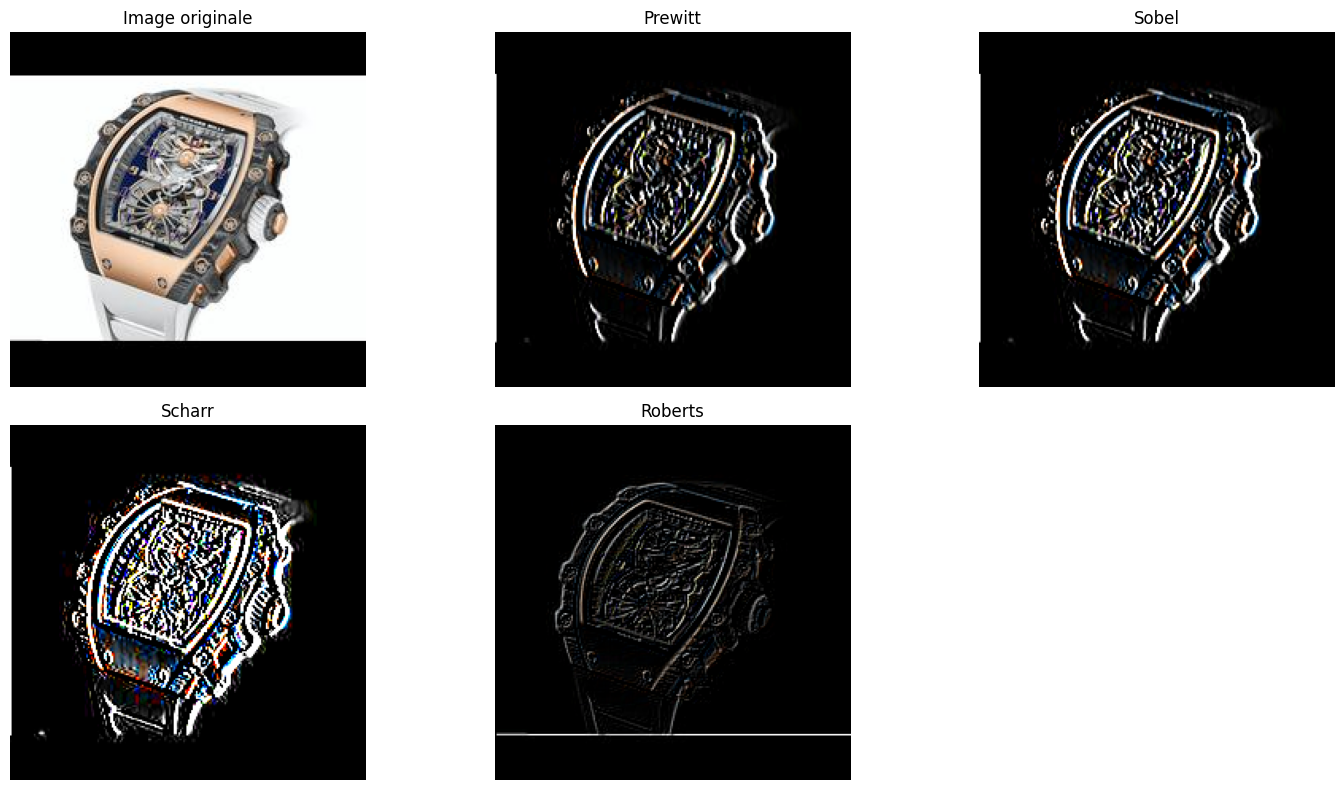

In [35]:
import cv2
import matplotlib.pyplot as plt

# Charger une image couleur
image_path = "BD_images_resized/Montres_37/image374.jpg"
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Filtres
prewitt_x, prewitt_y = filtre_prewitt()
sobel_x, sobel_y = filtre_sobel()
scharr_x, scharr_y = filtre_scharr()
roberts_x, roberts_y = filtre_roberts()
#laplacien_kernel = filtre_laplacien()  # <-- change ici

# Appliquer chaque filtre sur chaque canal puis reconstituer l'image couleur
def apply_filter_rgb(img_rgb, filtre):
    r = cross_correlation(img_rgb[:, :, 0], filtre, stride=1)
    g = cross_correlation(img_rgb[:, :, 1], filtre, stride=1)
    b = cross_correlation(img_rgb[:, :, 2], filtre, stride=1)
    return np.stack([r, g, b], axis=2).clip(0, 255).astype(np.uint8)

# Résultats
img_prewitt = apply_filter_rgb(img_rgb, prewitt_x)
img_sobel = apply_filter_rgb(img_rgb, sobel_x)
img_scharr = apply_filter_rgb(img_rgb, scharr_x)
img_roberts = apply_filter_rgb(img_rgb, roberts_x)
#img_laplacien = apply_filter_rgb(img_rgb, laplacien_kernel)

# Affichage
plt.figure(figsize=(15,8))
plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Image originale")
plt.axis('off')
plt.subplot(2,3,2)
plt.imshow(img_prewitt)
plt.title("Prewitt")
plt.axis('off')
plt.subplot(2,3,3)
plt.imshow(img_sobel)
plt.title("Sobel")
plt.axis('off')
plt.subplot(2,3,4)
plt.imshow(img_scharr)
plt.title("Scharr")
plt.axis('off')
plt.subplot(2,3,5)
plt.imshow(img_roberts)
plt.title("Roberts")
plt.axis('off')
"""plt.subplot(2,3,6)
plt.imshow(img_laplacien)
plt.title("Laplacien")
plt.axis('off')"""
plt.tight_layout()
plt.show()

Bruit

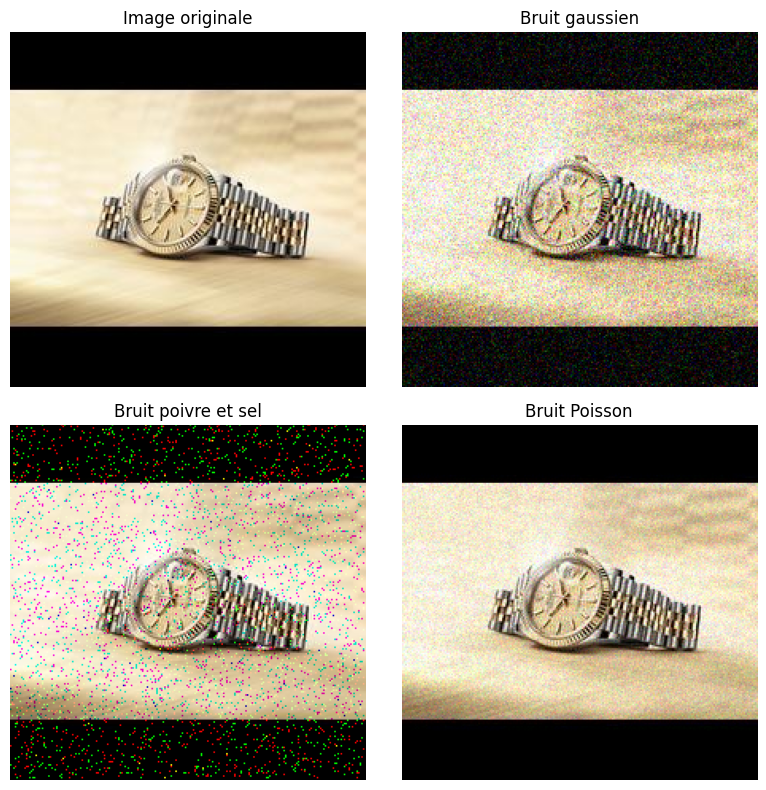

In [45]:
import numpy as np

def ajouter_bruit_gaussien(image, mean=0, sigma=20):
    """Ajoute un bruit gaussien à une image (uint8)."""
    bruit = np.random.normal(mean, sigma, image.shape)
    image_bruitee = image.astype(np.float32) + bruit
    return np.clip(image_bruitee, 0, 255).astype(np.uint8)

def ajouter_bruit_poivre_sel(image, proportion=0.05):
    """Ajoute un bruit poivre et sel à une image (uint8)."""
    img_bruitee = image.copy()
    nb_pixels = image.size
    nb_poivre = int(proportion * nb_pixels / 2)
    nb_sel = int(proportion * nb_pixels / 2)

    # Poivre (noir)
    coords = [np.random.randint(0, i - 1, nb_poivre) for i in image.shape]
    img_bruitee[tuple(coords)] = 0

    # Sel (blanc)
    coords = [np.random.randint(0, i - 1, nb_sel) for i in image.shape]
    img_bruitee[tuple(coords)] = 255

    return img_bruitee

def ajouter_bruit_poisson(image):
    """Ajoute un bruit de Poisson à une image (uint8)."""
    # Poisson attend des valeurs positives, donc on normalise si besoin
    image_float = image.astype(np.float32)
    # Génère le bruit de Poisson
    bruit = np.random.poisson(image_float).astype(np.float32)
    return np.clip(bruit, 0, 255).astype(np.uint8)

# Test sur une image couleur
import cv2
import matplotlib.pyplot as plt

image_path = "BD_images_resized/Montres_37/image371.jpg"
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_gauss = ajouter_bruit_gaussien(img_rgb, mean=0, sigma=30)
img_ps = ajouter_bruit_poivre_sel(img_rgb, proportion=0.05)
img_poisson = ajouter_bruit_poisson(img_rgb)

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Image originale")
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(img_gauss)
plt.title("Bruit gaussien")
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(img_ps)
plt.title("Bruit poivre et sel")
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(img_poisson)
plt.title("Bruit Poisson")
plt.axis('off')
plt.tight_layout()
plt.show()

